# Implementing Gaussian Mixture Model (GMM)

Import required libraries. make_blobs creates a simple synthetic dataset for demo.

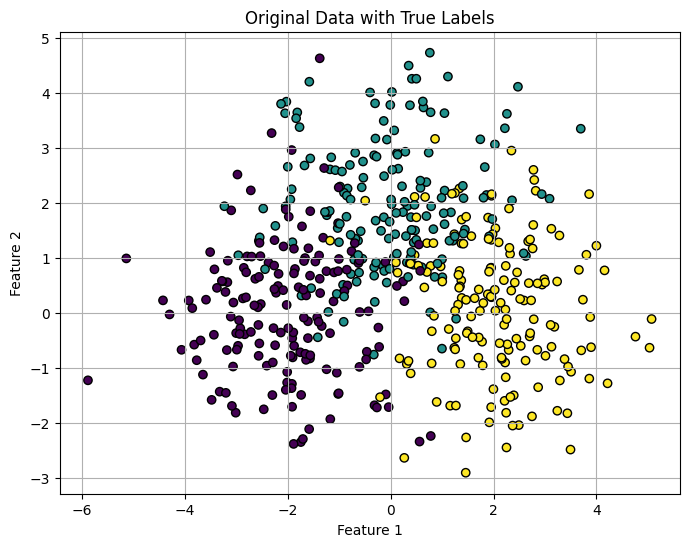

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs


# Generate synthetic data with overlapping clusters
# Creates 500 points in 2D grouped around 3 centers with significant mix
# Closer centers and larger cluster_std create overlapping clusters
centers = [[-2, 0], [0, 2], [2, 0]]  # Closer cluster centers for more overlap

X, Y = make_blobs(
    n_samples=500,
    centers=centers,
    random_state=42,
    cluster_std=1.2   # larger spread to create mixing between clusters
)

# Plot the original data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', marker='o', edgecolor='k')
plt.title('Original Data with True Labels')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.show()


#### <br>Step 2: Fit the Gaussian Mixture Model
- fit(X) runs the EM algorithm to learn means, covariances and mixing weights.
- labels gives the cluster index for each point (the component with highest posterior probability).

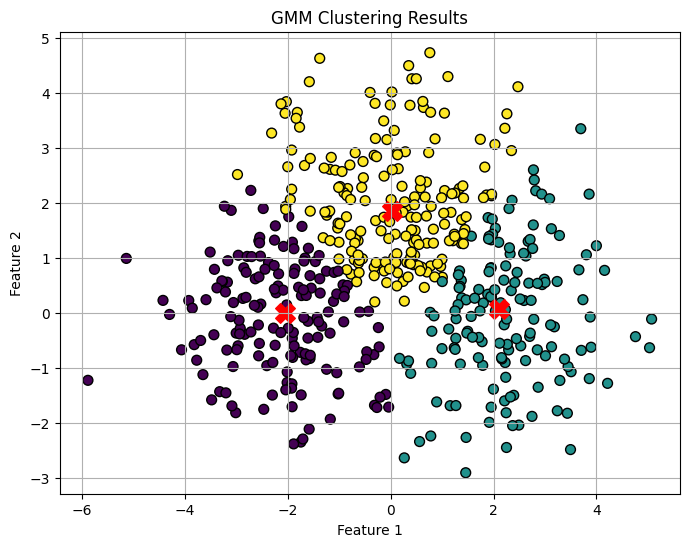

In [2]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',  # each component has its own covariance matrix
    random_state=42
)

gmm.fit(X)
labels = gmm.predict(X)

# Plot the GMM clustering results
plt.figure(figsize=(8, 6))

# Viridis is a colormap that provides a good range of colors for visualizing clusters.
# edgecolor='k' adds a black border around each point for better visibility.
# s=50 sets the size of the points in the scatter plot.
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', s=50, edgecolor='k')

# Plot Gaussian centroids
plt.scatter(
    gmm.means_[:, 0], 
    gmm.means_[:, 1], 
    c='red', 
    marker='X',
    s=200,  # size of the centroids
    label='Centroids'
)

plt.title('GMM Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.show()




## Use Cases with Examples

**Clustering** - Find customer groups by spending patterns (high spenders vs budget shoppers)

**Anomaly Detection** - Detect fraudulent credit card transactions (unusual spending patterns)

**Image Segmentation** - Separate foreground from background in medical imaging (tumor detection)

## Key Advantages

✓ **Soft Assignments**: Assigns probability scores instead of hard labels (90% cluster A, 10% cluster B)

✓ **Flexible Shapes**: Handles overlapping and ellipsoidal clusters, not just spheres

✓ **Interpretable**: Each cluster has a clear mean and covariance matrix

## Main Limitations

✗ **Sensitive to Initialization**: Starting values significantly affect results (may get stuck in local optima)

✗ **Computational Cost**: Slow on high-dimensional data (1000+ features)

✗ **Assumes Gaussian Shape**: Fails with non-Gaussian clusters (e.g., ring-shaped data)

✗ **Must Specify K**: Need to know number of clusters beforehand